TITANIC SURVIVAL PREDICTION

Dataset shape: (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          P

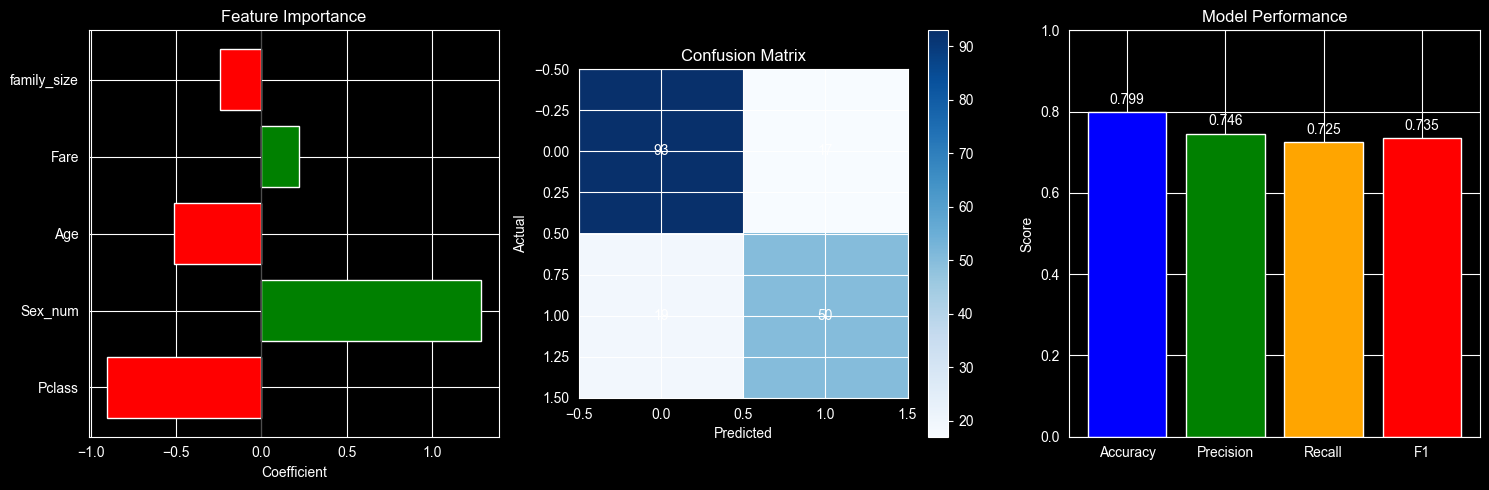


KEY INSIGHTS
1. Features with positive coefficients increase survival probability
2. Features with negative coefficients decrease survival probability
3. Compare your results to known Titanic patterns:
   - Women survived at higher rates (Sex should have positive coefficient)
   - First class passengers survived more (Pclass negative)


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import os

# ============================================
# PART 1: LOAD DATA
# ============================================

print("=" * 60)
print("TITANIC SURVIVAL PREDICTION")
print("=" * 60)

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())

# ============================================
# PART 2: EXPLORE DATA
# ============================================

print("\n" + "=" * 60)
print("DATA EXPLORATION")
print("=" * 60)

print(f"\nMissing values:")
print(df.isnull().sum())

print(f"\nSurvival rate: {df['Survived'].mean():.2%}")

# Check class distribution
print(f"\nClass distribution:")
print(df['Pclass'].value_counts())

# ============================================
# PART 3: FEATURE ENGINEERING
# ============================================

def prepare_features(df):
    """Convert raw Titanic data into features for logistic regression"""
    data = df.copy()
# 1. Create family_size = SibSp + Parch + 1
    data['family_size'] = data["SibSp"] + data["Parch"] + 1
# 2. Convert Sex to numeric: male=0, female=1
    data['Sex_num'] = data["Sex"].map({"male": 0, "female": 1})
# 3. Fill missing Age with median age
    data['Age'] = data['Age'].fillna(data['Age'].median())
# 4. Select only needed columns
    data = data.loc[:, ['Survived', 'Pclass', 'Sex_num', 'Age', 'Fare', 'family_size']]

    return data

# Apply feature engineering
df_processed = prepare_features(df)

# ============================================
# PART 4: PREPARE X AND y
# ============================================

# Target
y = df_processed['Survived'].values

# Features (select columns)
feature_cols = ['Pclass', 'Sex_num', 'Age', 'Fare', 'family_size']
X = df_processed[feature_cols].values

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")



# ============================================
# PART 5: TRAIN/VAL/TEST SPLIT
# ============================================

# Split into train (60%), validation (20%), test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

# ============================================
# PART 6: SCALE FEATURES
# ============================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ============================================
# PART 7: TRAIN MODEL
# ============================================

print("\n" + "=" * 60)
print("TRAINING LOGISTIC REGRESSION")
print("=" * 60)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Predict
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

# ============================================
# PART 8: EVALUATE
# ============================================

val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nValidation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Feature importance
print("\nFeature Importance (coefficients):")
for feature, coef in zip(feature_cols, model.coef_[0]):
    print(f"  {feature:12s}: {coef:8.4f}")

# ============================================
# PART 9: VISUALIZE
# ============================================

os.makedirs('week3_logistic_regression', exist_ok=True)

plt.figure(figsize=(15, 5))

# Plot 1: Feature importance
plt.subplot(1, 3, 1)
coefs = model.coef_[0]
colors = ['red' if c < 0 else 'green' for c in coefs]
plt.barh(feature_cols, coefs, color=colors)
plt.xlabel('Coefficient')
plt.title('Feature Importance')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Plot 2: Confusion Matrix
plt.subplot(1, 3, 2)
cm = confusion_matrix(y_test, y_test_pred)
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')

# Plot 3: Metrics
plt.subplot(1, 3, 3)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
values = [
    accuracy_score(y_test, y_test_pred),
    precision_score(y_test, y_test_pred),
    recall_score(y_test, y_test_pred),
    f1_score(y_test, y_test_pred)
]
plt.bar(metrics, values, color=['blue', 'green', 'orange', 'red'])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model Performance')
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.savefig('week3_logistic_regression/titanic_results.png')
plt.show()

print("\n" + "=" * 60)
print("KEY INSIGHTS")
print("=" * 60)
print("1. Features with positive coefficients increase survival probability")
print("2. Features with negative coefficients decrease survival probability")
print("3. Compare your results to known Titanic patterns:")
print("   - Women survived at higher rates (Sex should have positive coefficient)")
print("   - First class passengers survived more (Pclass negative)")